In [21]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.attractor_networks import HeadDirection
from grid_cells.plot_tools import angular_error, get_plot_grid, activity_map, smooth_ts
plt.rcParams.update({"font.size": 22})

import tqdm
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

In [22]:
T = 40
dt = 0.5e-3
n = 128
moon_position = np.array([0, 1, 1]) / np.sqrt(2)

In [23]:
bat_flight = generate_bat_flight(T=T, dt=dt, initial_heading=moon_position)
noise_levels = 0.005
rec_cells = list(np.random.randint(0, n, size=(8, 2)))
rec_cells.append(np.array([0, 0]))
net = HeadDirection(n=(n, n), dt=dt, use_single_bump=True, intrinsic_noise=noise_levels)
net.s[0, 0] = 100
net.warm_up()
recording = net.run_simulation(
    bat_flight["dir_vel"], rec_cells=rec_cells, n_snapshots=4000
)

100%|██████████| 79999/79999 [00:05<00:00, 15142.54it/s]


Ran warm up for 2003 steps


Running Simulation Steps: 100%|██████████| 80000/80000 [01:19<00:00, 1001.03it/s]


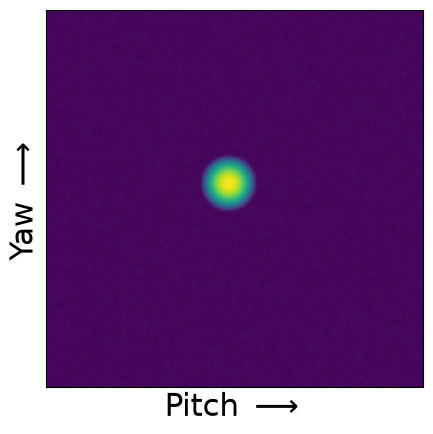

In [25]:
fig, ax = plt.subplots()

ax.imshow(
    recording["popuplation_snapshots"][-100]
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(r"Pitch $\longrightarrow$")
ax.set_ylabel(r"Yaw $\longrightarrow$")

fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "population_snapshot.svg"))

In [4]:
def smoothen(array: np.ndarray, interval: int):
    return (
        array[: (len(array) // interval) * interval].reshape(-1, interval).mean(axis=-1)
    )

In [5]:
list(np.arange(9).reshape(3, 3))

[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8])]

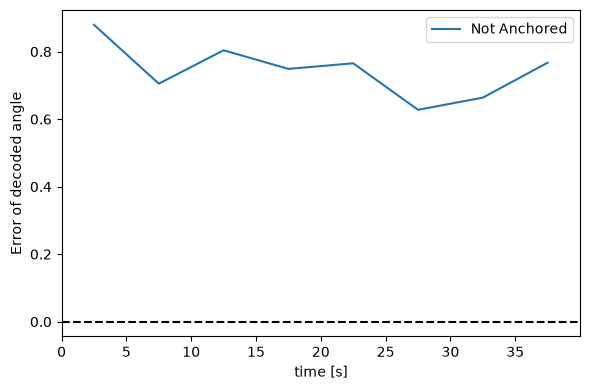

In [6]:
time_array = bat_flight["time"]
interval = 10000
fig, ax = plt.subplots(figsize=(6, 4))
azimuth_angular_error = np.linalg.norm(
    angular_error(recording["decoded_angle"], bat_flight["dir_torus"]),
    axis=-1,
)
ax.plot(
    smooth_ts(time_array, interval),
    smooth_ts(azimuth_angular_error, interval),
    label=f"Not Anchored",
    linestyle="-",
)
ax.legend(loc="best")
ax.axhline(y=0, color="black", linestyle="--")
ax.set_ylabel("Error of decoded angle")
ax.set_xlabel("time [s]")
ax.set_xlim(time_array.min(), time_array.max())

fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_direction_encoding_drift.svg"))

NameError: name 'activity_anchor' is not defined

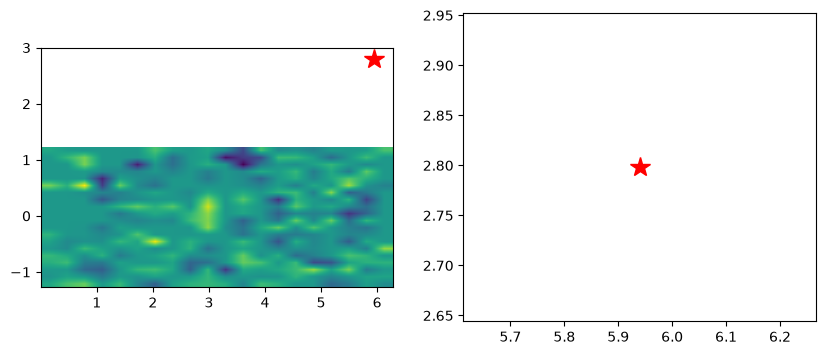

In [7]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
cell_index = 2
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"], recording["cell_recording"][:, cell_index], nbins=20
)
ax[0].imshow(
    activity.T,
    extent=(
        direction_edges[0][0],
        direction_edges[0][-1],
        direction_edges[1][0],
        direction_edges[1][-1],
    ),
    origin="lower",
    interpolation="bilinear",
)

encoding = (1 - recording["cell_indices"][cell_index] / n) * 2 * np.pi

ax[0].plot(
    *encoding,
    "r*",
    markersize=15,
)
ax[1].plot(
    *encoding,
    "r*",
    markersize=15,
)

ax[1].imshow(
    activity_anchor.T,
    extent=(
        direction_edges[0][0],
        direction_edges[0][-1],
        direction_edges[1][0],
        direction_edges[1][-1],
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[0].set_title("Not Anchored")
ax[1].set_title("Anchored")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_firing_field_drift.svg"))

In [ ]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

vmin, vmax = min(
    recording["popuplation_snapshots"].min(),
    recording_with_anchor["popuplation_snapshots"].min(),
), max(
    recording["popuplation_snapshots"].max(),
    recording_with_anchor["popuplation_snapshots"].max(),
)


def update(frame):
    ax[0].clear()
    ax[1].clear()
    ax[0].imshow(
        recording["popuplation_snapshots"][frame],
        cmap="viridis",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    ax[0].set_title(
        f"Not Anchored (t={bat_flight["time"][recording['snapshot_indices'][frame]]:.2f})"
    )
    ax[1].imshow(
        recording_with_anchor["popuplation_snapshots"][frame],
        cmap="viridis",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    ax[1].set_title(
        f"Anchored (t={bat_flight["time"][recording_with_anchor['snapshot_indices'][frame]]:.2f})"
    )

    # Add true location marker
    snapshot_idx = recording["snapshot_indices"][frame]
    true_angle = bat_flight["dir_torus"][snapshot_idx]
    true_pos = ((2 * np.pi - true_angle) / (2 * np.pi) * n).astype(int)

    for axis in ax:
        axis.plot(
            true_pos[1],
            true_pos[0],
            "r*",
            markersize=15,
        )


frames = int(len(recording["popuplation_snapshots"]) / 4)

anim = FuncAnimation(
    fig,
    update,
    frames=range(0, frames),
    interval=50,
    repeat=True,
)
anim.save(
    os.path.join(PLOTS_DIR, "bat_flight_3d_population_movie.gif"), writer="pillow"
)

In [ ]:
n_landmarks = 40

anchors = np.random.uniform(0, 2 * np.pi, size=(n_landmarks, 2))
anchors = np.concat([anchors, np.array([np.pi, np.pi])[np.newaxis, :]])

In [ ]:
## Simulation parameters:
n_min_plots = 4
dt = 0.5e-3
n = 128

net = HeadDirection(n=n, dt=dt, use_single_bump=True)


def make_anchor_weight(anchor, sigma=0.25):
    def weight_func(position):
        err = angular_error(position, anchor)
        d2 = np.sum(err**2)
        return np.exp(-d2 / (2 * sigma**2))

    return weight_func


for anchor in anchors:
    net.add_anchor_point(
        weight_func=make_anchor_weight(anchor, sigma=0.1),
        strength=0.1,
        mask=net.encode_orientation(anchor, width=0.1),
    )


error = 0.5
net.s = net.encode_orientation([np.pi - error, np.pi])

net.warm_up()
ncols = np.int64(np.ceil(np.sqrt(n_min_plots)))
nrows = np.int64(np.ceil(n_min_plots / ncols))
n_plots = nrows * ncols
fig, ax = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
ax = ax.flatten()
n_steps = 1000
records = np.linspace(0, n_steps - 1, n_plots, dtype=int)
plot_counter = 0
time = 0
true_angle = np.array([np.pi - error / 3, np.pi - error / 3])
for step_iter in range(n_steps):
    if step_iter == records[plot_counter]:
        ax[plot_counter].imshow(net.s, origin="lower")
        phi_decoded, theta_decoded = net.decode_orientation()
        ax[plot_counter].set_title(
            r" dec: " + f"({phi_decoded/np.pi:.2f},{theta_decoded/np.pi:.2f})"
        )
        ax[plot_counter].scatter(*(1 - anchors.T / (2 * np.pi)) * n)
        plot_counter += 1
    net.step(0, 0, pos=true_angle)
    time += dt
fig.suptitle(r"true: " + f"{true_angle[0]/np.pi:.2f},{true_angle[1]/np.pi:.2f}")
fig.tight_layout()